In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [32]:
data = pd.read_csv("../data/processed/data_preprocessed.csv",encoding='latin-1')
data.head()

,Unnamed: 0,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,...,Order State,Order Status,Product Card Id,Product Category Id,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,...,Java Occidental,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,...,RajastÃ¡n,PENDING,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,...,RajastÃ¡n,CLOSED,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,...,Queensland,COMPLETE,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,...,Queensland,PENDING_PAYMENT,1360,73,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [33]:
df = data[
    [
        'Customer Id',
        'Order Id',
        'Sales',
        'order date (DateOrders)',
        'Department Name',
        'Order Item Discount',
        'Order Profit Per Order',
        'Order Item Discount Rate'
    ]
]
df

,Customer Id,Order Id,Sales,order date (DateOrders),Department Name,Order Item Discount,Order Profit Per Order,Order Item Discount Rate
0,20755,77202,327.750000,1/31/2018 22:56,Fitness,13.110000,91.250000,0.04
1,19492,75939,327.750000,1/13/2018 12:27,Fitness,16.389999,-249.089996,0.05
2,19491,75938,327.750000,1/13/2018 12:06,Fitness,18.030001,-247.779999,0.06
3,19490,75937,327.750000,1/13/2018 11:45,Fitness,22.940001,22.860001,0.07
4,19489,75936,327.750000,1/13/2018 11:24,Fitness,29.500000,134.210007,0.09
...,...,...,...,...,...,...,...,...
180514,1005,26043,399.980011,1/16/2016 3:40,Fan Shop,0.000000,40.000000,0.00
180515,9141,26037,399.980011,1/16/2016 1:34,Fan Shop,4.000000,-613.770019,0.01
180516,291,26024,399.980011,1/15/2016 21:00,Fan Shop,8.000000,141.110001,0.02
180517,2813,26022,399.980011,1/15/2016 20:18,Fan Shop,12.000000,186.229996,0.03


Creating Recency, Frequency and Monetary(RFM)

In [34]:
df['order date (DateOrders)'] = pd.to_datetime(df['order date (DateOrders)'])
snapshot_date = (df['order date (DateOrders)'].max()+ pd.Timedelta(days=1))
rfm = (df.groupby('Customer Id').agg({'order date (DateOrders)': lambda x:(snapshot_date - x.max()).days,
                                      'Order Id': 'nunique',
                                      'Sales': 'sum'}).reset_index())
rfm.columns = ['Customer Id','Recency','Frequency','Monetary']
rfm

,Customer Id,Recency,Frequency,Monetary
0,1,793,1,499.950012
1,2,137,4,1819.730034
2,3,230,5,3537.680094
3,4,381,4,1719.630030
4,5,458,3,1274.750023
...,...,...,...,...
20647,20753,1,1,215.820007
20648,20754,1,1,215.820007
20649,20755,1,1,327.750000
20650,20756,1,1,11.540000


Average Order Value

In [35]:
rfm['Avg_Order_Value']=rfm['Monetary']/rfm['Frequency']

Product Category Diversity

In [36]:
category_diversity = (df.groupby("Customer Id")["Department Name"].nunique())
rfm['Unique_Product_Categories']=category_diversity
rfm.head()

,Customer Id,Recency,Frequency,Monetary,Avg_Order_Value,Unique_Product_Categories
0,1,793,1,499.950012,499.950012,NaN
1,2,137,4,1819.730034,454.932508,1.0
2,3,230,5,3537.680094,707.536019,3.0
3,4,381,4,1719.630030,429.907507,4.0
4,5,458,3,1274.750023,424.916674,4.0


Discount Behavior

In [37]:
# Average discount rate per customer
avg_discount_rate = (df.groupby("Customer Id")["Order Item Discount Rate"].mean())
rfm['Avg_Discount_Rate']=round(avg_discount_rate,2)
rfm.head()

,Customer Id,Recency,Frequency,Monetary,Avg_Order_Value,Unique_Product_Categories,Avg_Discount_Rate
0,1,793,1,499.950012,499.950012,NaN,NaN
1,2,137,4,1819.730034,454.932508,1.0,0.06
2,3,230,5,3537.680094,707.536019,3.0,0.13
3,4,381,4,1719.630030,429.907507,4.0,0.11
4,5,458,3,1274.750023,424.916674,4.0,0.14


Total Profitability

In [38]:
total_profit = (df.groupby("Customer Id")["Order Profit Per Order"].sum())
rfm['Total_Profit']=total_profit

In [39]:
rfm.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
Customer Id,20652.0,10400.285929,5993.106225,1.000000,5208.750000,10407.500000,15594.250000,20757.000000
Recency,20652.0,221.089144,199.395441,1.000000,76.000000,160.000000,308.000000,1126.000000
Frequency,20652.0,3.183808,2.430699,1.000000,1.000000,3.000000,5.000000,15.000000
Monetary,20652.0,1781.170589,1677.328081,11.290000,293.040008,1499.825033,2915.880065,10524.170178
Avg_Order_Value,20652.0,476.102243,291.066058,11.290000,260.649994,473.013636,641.943516,1759.890015
Unique_Product_Categories,20546.0,2.869026,1.729007,1.000000,1.000000,3.000000,4.000000,6.000000
Avg_Discount_Rate,20546.0,0.101777,0.048194,0.000000,0.080000,0.100000,0.120000,0.250000
Total_Profit,20546.0,192.961743,389.884469,-3868.559982,5.385000,111.709997,399.732500,2441.970003


In [40]:

print("Missing values:")
print(rfm.isnull().sum())

print("Duplicate rows:", rfm.duplicated().sum())

print("Unique customers:", rfm["Customer Id"].nunique())

Missing values:
Customer Id                    0
Recency                        0
Frequency                      0
Monetary                       0
Avg_Order_Value                0
Unique_Product_Categories    106
Avg_Discount_Rate            106
Total_Profit                 106
dtype: int64
Duplicate rows: 0
Unique customers: 20652


In [41]:
numeric_columns = ["Recency","Frequency","Monetary","Avg_Order_Value","Unique_Product_Categories","Avg_Discount_Rate","Total_Profit"]

skewness = rfm[numeric_columns].skew().sort_values(ascending=False)
print(skewness)


Recency                      1.514646
Monetary                     0.902301
Frequency                    0.898097
Avg_Order_Value              0.770439
Avg_Discount_Rate            0.430348
Unique_Product_Categories    0.127384
Total_Profit                -0.143213
dtype: float64


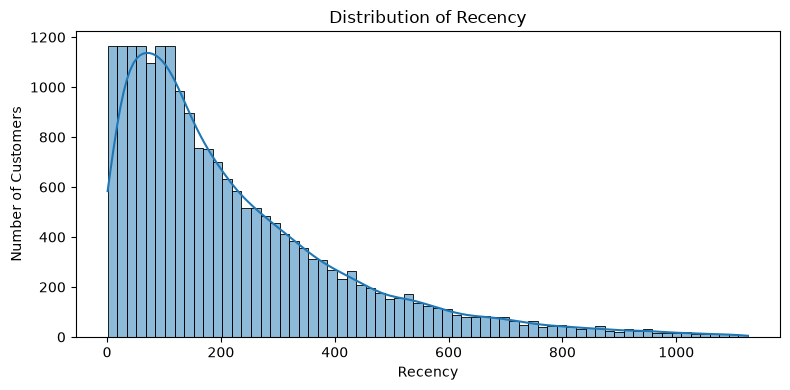

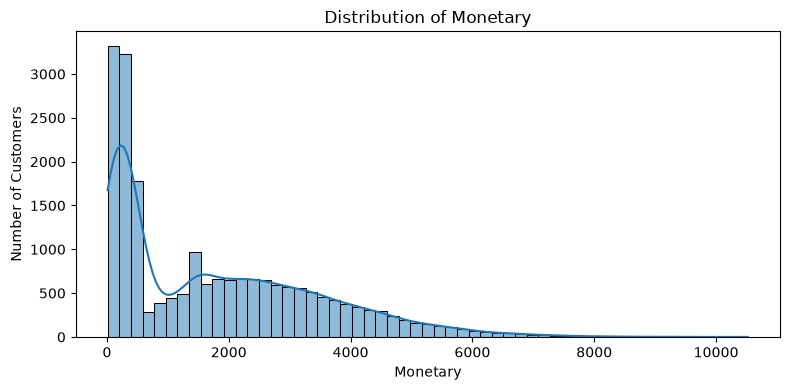

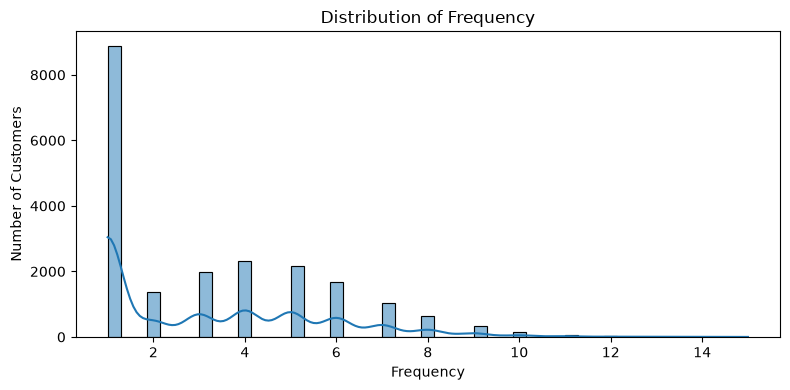

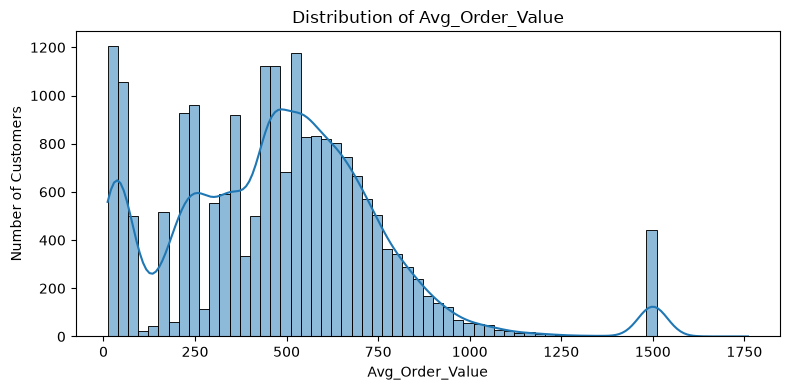

In [42]:
important_columns = ["Recency","Monetary","Frequency","Avg_Order_Value"]

for column in important_columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=rfm,x=column,kde=True)

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Number of Customers")
    plt.tight_layout()
    plt.show()

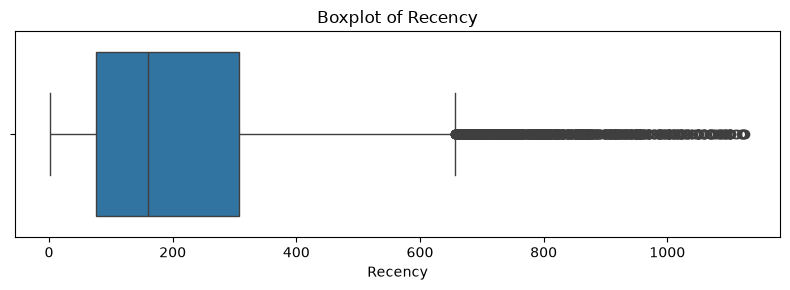

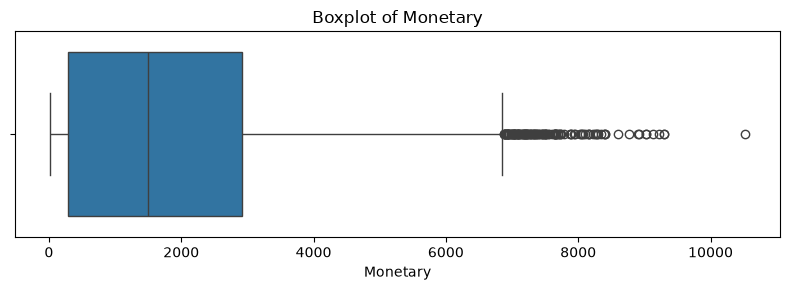

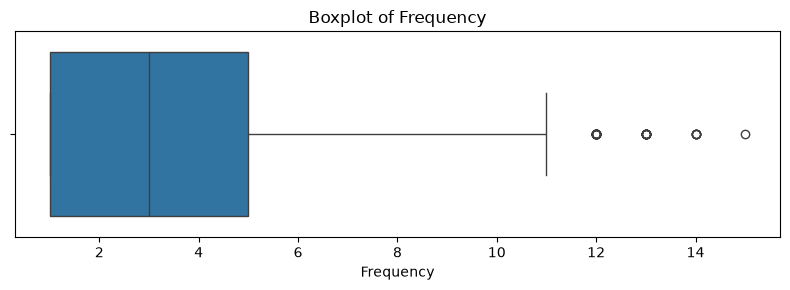

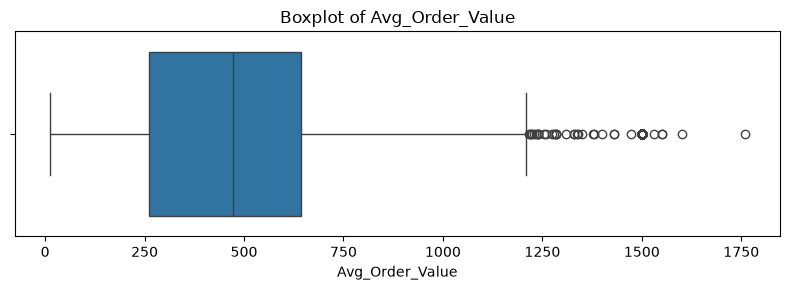

In [43]:
for column in important_columns:
    plt.figure(figsize=(8, 3))
    sns.boxplot(data=rfm,x=column)
    plt.title(f"Boxplot of {column}")
    plt.tight_layout()
    plt.show()

In [44]:
rfm.to_csv("rfm data/rfm.csv", index=False)